# Model Training Notebook Template

> **Purpose:** Use this notebook to document the full machine learning model development process for your project.  
> It is designed as a **deliverable template** for the task and can be adapted for classification, regression, forecasting, recommendation, anomaly detection, or clustering problems.

---

## How to use this notebook
1. Duplicate this notebook for your project.
2. Rename the notebook model_training_notebook_<student_number>.ipynb
3. Replace all placeholders marked with `TODO`.
4. Keep the narrative concise but evidence-based.
5. Record each important experiment, metric, and decision.
6. Make sure the final notebook clearly shows:
   - the problem being solved
   - the data used
   - the baseline
   - the models tried
   - evaluation and validation
   - error analysis
   - iterations and improvements
   - the final recommendation and business value
7. Make sure the final notebook is saved in your individual GitHub repo.
8. Make sure the notebook meets the [notebook submission guidelines](https://adsai.buas.nl/General/NotebookSubmissionRules.html).

---

## Deliverable alignment
This notebook is structured to support the required deliverable:

- **Model training notebook**
- Evidence for:
  - **ILO 8.4 A:** why the model is an appropriate solution
  - **ILO 8.4 B:** metrics, validation performance, limitations, and common errors
  - **ILO 8.4 C:** key iterations and how they improved performance

## Individual Deliverable

Note this notebook should be completed individually. Each member of the group is responsible for training and analysing their own model. You are free to choose which model or models your team chooses to integrate into your application.
This submission should be unique if your submission is too similar to other members of your group or the class your case will be assessed for academic dishonesty and may be referred to the BOE.


## 0. Project metadata

- **Project title:** MSFT Direction Predictor — predicting next-day price direction of Microsoft stock
- **Notebook owner / author:** Gergely Gádor (250713)


## 1. Problem definition

### 1.1 Prediction or analysis task

The model performs binary classification on Microsoft (MSFT) stock: given
historical price data and a small set of exogenous market signals available
up to the end of trading day *t*, predict whether the closing price on day
*t+1* will move up or down. The input is a single feature row representing
the most recent trading day (OHLCV for MSFT, daily closing prices for gold
and crude oil, the VIX volatility index, plus a few engineered lag and
rolling features); the output is a single binary label (1 = UP, 0 = DOWN)
together with a probability of the UP class. The end users are retail
investors interacting with the Streamlit dashboard that reads from the
project's SQLite database.

### 1.2 Business or project value

The model is intended to support short-term trading and risk-management
decisions for retail investors who do not have access to professional
quant-finance tooling. Even modest improvements in direction accuracy can
help users size positions, set stop-loss levels, and decide whether to
hold or rotate out of a position before the next session. The risk of a
poorly performing model is real: a tool that signals UP when the true
distribution is essentially noise gives users false confidence and can
lead to financially costly decisions. For this reason the deliverable
prioritises an honest, well-calibrated assessment of model performance
over a headline accuracy number.

### 1.3 Success criteria

The primary metric is **F1 score** on the binary direction target,
matching the proposal's evaluation framework and reflecting the cost of
both false positives (entering a long position before a down day) and
false negatives (sitting out an up day). A reasonable minimum success
threshold is "beats a random or majority-class baseline", roughly
F1 > 0.60 on the test window. Secondary constraints that matter for the
dashboard deliverable are: (i) the model must produce probabilities, not
only hard labels, so users see confidence; (ii) it must run fast enough
at prediction time that the dashboard remains interactive; (iii) it must
be interpretable enough that we can explain *why* a particular day was
predicted UP or DOWN.


## 2. Data selection and preparation

### 2.1 Dataset summary

- **Data source(s):** Four CSV files originally drawn from the Nasdaq-100
  repository, merged and stored in the shared SQLite database at
  `db/stocks.db`: `msft_daily` (MSFT OHLCV), `gold_prices`, `oil_prices`,
  and `vix_data` (VIX from the macroeconomic indicators dataset).
- **Collection period:** February 2015 through April 2026 (the database
  has been refreshed with recent data; the original proposal window was
  Feb 2015 – Feb 2025).
- **Unit of analysis:** one trading day. Each row represents the state
  of the market at end-of-day *t*; the target represents direction on
  day *t+1*.
- **Target variable:** binary, derived from the next-day percentage
  return on MSFT close. UP = next-day return greater than +0.5%,
  DOWN = next-day return less than −0.5%. Days inside the ±0.5% band
  are treated as neutral and removed from the dataset.
- **Key features:** OHLCV for MSFT; daily close of gold, oil, and the VIX;
  engineered features added by the pipeline (`lag_1`, `lag_2`,
  `rolling_5`, `rolling_10`, `daily_return`, `price_range`,
  `gold_return`, `oil_return`). All features are scaled with
  `RobustScaler` fitted only on training data.
- **Important exclusions or filters:** the ±0.5% neutral zone around
  zero return, removing 552 rows that carry no directional signal. One
  oil-price row (2020-04-20, the negative-oil-price event) was rejected
  by the Pydantic validator since the model assumes positive values.

### 2.2 Risks and limitations

- **Missing values:** the four sources have slightly different trading
  calendars. The pipeline aligns to MSFT trading days and forward-fills
  small gaps for the exogenous series; zero rows remain missing after
  this step.
- **Sampling bias:** the dataset covers a single stock over a period
  dominated by the 2020–2022 monetary cycle and the post-COVID recovery,
  so any patterns learned may not generalise to other regimes.
- **Label quality issues:** the binary target depends entirely on the
  ±0.5% threshold. A different threshold would produce a different
  dataset and different class balance. The choice is documented and
  defensible but it is a modelling decision, not a property of the data.
- **Leakage risks:** the main risk is using day *t+1* information to
  predict day *t+1*. The split is strictly time-based with no shuffling,
  the scaler is fit on training data only, and engineered features use
  only past values (`shift`, rolling windows ending at *t*).
- **Ethical/privacy concerns:** the data is publicly available market
  data. No personal information is involved. The downstream dashboard
  must, however, present model predictions with appropriate uncertainty
  framing so users are not misled into treating output as advice.


In [1]:
"""
Section 2 + 3 — Data loading, preprocessing, and time-based split.

This notebook reuses the group's preprocessing pipeline rather than
re-implementing the steps. All data loading, validation, merging, target
creation, feature engineering, scaling, and the time-based train/test
split happen inside `run_pipeline()` from
`src/msft_forecaster/pipeline/preprocess.py`.

Paths are resolved dynamically from the notebook's location so this works
regardless of which working directory the notebook is launched from.
"""

# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------
import logging
import sys
from pathlib import Path

# ---------------------------------------------------------------------------
# Resolve repo root by walking upward from the notebook until we find the
# pyproject.toml. This works whether the notebook is launched from its own
# folder, the repo root, or anywhere in between. Marker-file based so it
# survives the notebook being moved within the repo.
# ---------------------------------------------------------------------------
def _find_repo_root(marker: str = "pyproject.toml") -> Path:
    """Walk upward from the current working directory to find the repo root.

    The repo root is identified by the presence of `marker` (default
    pyproject.toml). Raises FileNotFoundError if no marker is found before
    hitting the filesystem root.
    """
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not locate {marker} above {here}. "
        f"Make sure the notebook is being run from inside the repo."
    )


REPO_ROOT = _find_repo_root()
SRC_DIR = REPO_ROOT / "src"
DB_PATH = REPO_ROOT / "db" / "stocks.db"
MODELS_DIR = REPO_ROOT / "models" / "gergely"

# Ensure src/ is importable. This is a no-op if Poetry already installed
# msft_forecaster as an editable package; it's a rescue if not.
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Create models/gergely/ so the scaler and ensemble pickles have somewhere
# to land later. Idempotent.
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root:  {REPO_ROOT}")
print(f"DB path:    {DB_PATH}  (exists: {DB_PATH.exists()})")
print(f"Models dir: {MODELS_DIR}")


# ---------------------------------------------------------------------------
# Run the group's preprocessing pipeline
# ---------------------------------------------------------------------------
# The pipeline does: load tables from SQLite -> Pydantic validation ->
# merge on date -> forward-fill missing values -> create binary target with
# a 0.5% neutral-zone threshold -> engineer lag, rolling, return and range
# features -> RobustScaler fit on training data only -> 80/20 time-based
# split -> write the processed features back to a `processed_features`
# table in the same SQLite DB.
from msft_forecaster.pipeline.preprocess import run_pipeline  # noqa: E402

# Save the scaler to gergely/ so this notebook does not overwrite a
# group-level scaler at models/scaler.pkl.
SCALER_PATH = MODELS_DIR / "scaler_gergely_ensemble.pkl"

X_train, X_test, y_train, y_test, train_df, test_df, scaler = run_pipeline(
    db_path=str(DB_PATH),
    scaler_path=str(SCALER_PATH),
)

logging.getLogger(__name__).info(
    "Pipeline finished. X_train=%s  X_test=%s  positive rate (train)=%.3f",
    X_train.shape, X_test.shape, float(y_train.mean()),
)


Repo root:  C:\Users\Gergi\Documents\GitHub\2025-26d-fai1-adsai-group_15
DB path:    C:\Users\Gergi\Documents\GitHub\2025-26d-fai1-adsai-group_15\db\stocks.db  (exists: True)
Models dir: C:\Users\Gergi\Documents\GitHub\2025-26d-fai1-adsai-group_15\models\gergely


2026-05-26 03:50:32,552 - INFO - Starting preprocessing pipeline...
2026-05-26 03:50:32,563 - INFO - msft_daily: schema valid — all expected columns present
2026-05-26 03:50:32,564 - INFO - gold_prices: schema valid — all expected columns present
2026-05-26 03:50:32,565 - INFO - oil_prices: schema valid — all expected columns present
2026-05-26 03:50:32,565 - INFO - vix_data: schema valid — all expected columns present
2026-05-26 03:50:32,570 - INFO - Loaded from database: msft=1842, gold=1843, oil=1843, vix=1863
2026-05-26 03:50:32,625 - INFO - msft_daily: all 1842 rows passed validation
2026-05-26 03:50:32,723 - INFO - gold_prices: all 1843 rows passed validation
2026-05-26 03:50:32,743 - WARNING - oil_prices — invalid row dropped (date=2020-04-20 00:00:00): 1 validation error for ExternalRecord
value
  Value error, Value must be positive, got -37.630001068115234 [type=value_error, input_value=-37.630001068115234, input_type=float]
    For further information visit https://errors.pyd

### 2.3 Initial data inspection

After the full pipeline has run:

- **Number of rows:** 1,281 trading days after filtering and feature
  engineering (down from 1,842 raw MSFT rows; 552 neutral days excluded
  by the threshold, 9 dropped by the rolling-window warm-up).
- **Number of columns:** 35 in `train_df`/`test_df`, comprising the
  original 9 raw + target columns, 9 engineered features, and the
  RobustScaler-transformed versions of the 16 modelling features.
- **Target balance:** 54.6% UP (700 rows) / 45.4% DOWN (581 rows). Mild
  imbalance toward the UP class — enough to bias models trained without
  class weighting toward UP predictions, but not enough to require
  resampling.
- **Data types:** date is `datetime64[us]`; all numeric features are
  `float64` except the target which is `int64`. No object/string columns
  remain after preprocessing.
- **Key issues in the raw data:** one validation error on
  `oil_prices` (negative price on 2020-04-20, the COVID oil-price
  collapse) — caught and dropped by the Pydantic validator. No other
  schema issues. The summary statistics on engineered features look
  plausible (daily-return mean essentially zero, max ~14% which aligns
  with documented MSFT moves during the 2020 volatility spike).


In [2]:
"""
Section 2.3 — initial data inspection on the merged + engineered dataset.
The dataset is already in scope as `train_df` and `test_df` from the
`run_pipeline()` call in section 2.
"""

# ---------------------------------------------------------------------------
# Imports — pandas is already loaded transitively via preprocess.py, but
# we import explicitly here so the cell is self-contained.
# ---------------------------------------------------------------------------
import pandas as pd

# Combine train and test for a global view of the dataset. Splitting is
# already done; this is just for inspection.
full_df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Total rows: {len(full_df)}")
print(f"Total cols: {full_df.shape[1]}")
print(f"Date range: {full_df['date'].iloc[0]} -> {full_df['date'].iloc[-1]}\n")

# Target balance after the 0.5% neutral-zone filter applied by preprocess.py.
# A roughly 50/50 split is expected; large imbalance would change which
# metrics we should prioritise.
target_counts = full_df["target"].value_counts().sort_index()
target_props = full_df["target"].value_counts(normalize=True).sort_index()
print("Target distribution (0 = DOWN, 1 = UP):")
print(pd.DataFrame({"count": target_counts, "proportion": target_props.round(3)}))

# Dtypes — quick sanity check that numeric features came through as numeric
# and the date is a datetime / object as expected.
print("\nColumn dtypes:")
print(full_df.dtypes)

# Missingness — should be zero after the pipeline's forward-fill + dropna,
# but worth confirming so we catch any regression in preprocess.py.
missing = full_df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("\nNo missing values remain after preprocessing.")
else:
    print("\nWARNING: missing values detected:")
    print(missing)

# Head + a few summary stats on the key engineered features.
print("\nFirst rows:")
display(full_df.head())  # noqa: F821  (display is provided by IPython)

print("\nSummary statistics on engineered features:")
engineered = ["lag_1", "lag_2", "rolling_5", "rolling_10",
              "daily_return", "price_range", "gold_return", "oil_return"]
display(full_df[engineered].describe().round(4))  # noqa: F821


Total rows: 1281
Total cols: 35
Date range: 2019-01-17 00:00:00 -> 2026-04-29 00:00:00

Target distribution (0 = DOWN, 1 = UP):
        count  proportion
target                   
0         581       0.454
1         700       0.546

Column dtypes:
date                   datetime64[us]
open                          float64
high                          float64
low                           float64
close                         float64
volume                        float64
gold_close                    float64
oil_close                     float64
vix                           float64
next_return                   float64
target                          int64
lag_1                         float64
lag_2                         float64
rolling_5                     float64
rolling_10                    float64
daily_return                  float64
price_range                   float64
gold_return                   float64
oil_return                    float64
open_scaled                   

,date,open,high,low,close,volume,gold_close,oil_close,vix,next_return,...,oil_close_scaled,vix_scaled,lag_1_scaled,lag_2_scaled,rolling_5_scaled,rolling_10_scaled,daily_return_scaled,price_range_scaled,gold_return_scaled,oil_return_scaled
0,2019-01-17,105.00,106.625,104.76,106.12,28393015.0,1291.000000,52.070000,18.06,0.014983,...,-0.722514,-0.118797,-1.219873,-1.238738,-1.184733,-1.164482,0.028618,-0.836887,-0.099231,-0.196476
1,2019-01-18,107.46,107.900,105.91,107.71,37427587.0,1281.300049,53.799999,17.80,-0.018847,...,-0.656414,-0.145539,-1.213743,-1.211327,-1.178201,-1.159376,0.319779,-0.802588,-0.705837,0.901779
2,2019-01-22,106.75,107.100,104.86,105.68,32371253.0,1282.500000,52.570000,20.80,0.009746,...,-0.703410,0.163024,-1.200572,-1.205235,-1.173624,-1.152959,-0.917523,-0.733989,0.021335,-0.727250
3,2019-01-24,106.86,107.000,105.34,106.20,23164838.0,1279.099976,53.130001,18.89,0.009134,...,-0.682013,-0.033428,-1.217388,-1.192147,-1.167029,-1.149751,-0.048250,-0.893137,-0.287398,0.246181
4,2019-01-25,107.24,107.880,106.59,107.17,31205188.0,1297.400024,53.689999,17.42,-0.019502,...,-0.660617,-0.184623,-1.213080,-1.208857,-1.164184,-1.146365,0.105844,-0.994663,1.171939,0.242918



Summary statistics on engineered features:


,lag_1,lag_2,rolling_5,rolling_10,daily_return,price_range,gold_return,oil_return
count,1281.0000,1281.0000,1281.0000,1281.0000,1281.0000,1281.0000,1281.0000,1281.0000
mean,294.7860,294.5305,294.5332,293.9060,0.0013,6.0165,0.0004,0.0019
std,110.3748,110.4419,110.3167,110.3605,0.0216,3.5809,0.0286,0.0553
min,102.7800,102.0500,103.9900,102.7600,-0.1474,0.5950,-0.9075,-0.5708
25%,212.4200,212.2500,212.3880,211.7890,-0.0120,3.6200,-0.0051,-0.0177
50%,281.7800,281.7700,282.2620,282.0980,0.0059,5.4094,0.0010,0.0021
75%,393.8747,393.8700,393.6753,395.2920,0.0143,7.5597,0.0073,0.0207
max,539.3073,539.3073,526.4110,521.7153,0.1422,39.8251,0.0643,0.3766


### 2.4 Preprocessing decisions

All preprocessing is delegated to the shared group pipeline
(`src/msft_forecaster/pipeline/preprocess.py`) so every team member's
notebook works from an identical feature set. The pipeline does the
following:

- **Missing values** are forward-filled to align the gold/oil/VIX
  calendars to MSFT trading days. Zero rows are dropped for missingness.
- **Categorical encoding** is not needed — every feature is already
  numeric.
- **Numeric scaling** uses `RobustScaler` rather than `StandardScaler`
  because financial data contains real outliers (the March 2020 COVID
  drop, individual earnings surprises) that we want the model to see,
  but that should not distort the scaling parameters themselves.
  RobustScaler uses median and IQR instead of mean and standard
  deviation. Critically, the scaler is fit on the training rows only
  and the saved scaler object is reused at prediction time for the
  dashboard.
- **Feature engineering** adds short-term price memory (`lag_1`,
  `lag_2`), medium-term trend (`rolling_5`, `rolling_10`), normalised
  price change (`daily_return`), intraday volatility (`price_range`),
  and external-asset returns (`gold_return`, `oil_return`).
- **Feature removal:** the original `close` column is *not* removed
  despite being highly correlated with `lag_1` and the rolling means.
  Tree-based models handle multicollinearity natively, and removing it
  would also hurt the linear models we use as iteration 1.
- **Time-based split:** 80% train / 20% test, ordered strictly by date,
  no shuffling. This is the canonical setup for a forecasting problem
  and aligns with the proposal.
- **Saving:** the processed feature table is written back to a
  `processed_features` table in `db/stocks.db` so the dashboard can
  read it without re-running preprocessing.


In [3]:
# Preprocessing is handled by `run_pipeline()` in the cell above.
# It performs: merge on date, forward-fill missing values, target
# creation with a 0.5% neutral threshold, lag/rolling/return feature
# engineering, and RobustScaler fitted on training data only. See
# src/msft_forecaster/pipeline/preprocess.py for the implementation.
print(f'Engineered features: {train_df.shape[1]} columns, '
      f'{len(train_df)} train rows, {len(test_df)} test rows.')
train_df.head()


Engineered features: 35 columns, 1024 train rows, 257 test rows.


,date,open,high,low,close,volume,gold_close,oil_close,vix,next_return,...,oil_close_scaled,vix_scaled,lag_1_scaled,lag_2_scaled,rolling_5_scaled,rolling_10_scaled,daily_return_scaled,price_range_scaled,gold_return_scaled,oil_return_scaled
0,2019-01-17,105.00,106.625,104.76,106.12,28393015.0,1291.000000,52.070000,18.06,0.014983,...,-0.722514,-0.118797,-1.219873,-1.238738,-1.184733,-1.164482,0.028618,-0.836887,-0.099231,-0.196476
1,2019-01-18,107.46,107.900,105.91,107.71,37427587.0,1281.300049,53.799999,17.80,-0.018847,...,-0.656414,-0.145539,-1.213743,-1.211327,-1.178201,-1.159376,0.319779,-0.802588,-0.705837,0.901779
2,2019-01-22,106.75,107.100,104.86,105.68,32371253.0,1282.500000,52.570000,20.80,0.009746,...,-0.703410,0.163024,-1.200572,-1.205235,-1.173624,-1.152959,-0.917523,-0.733989,0.021335,-0.727250
3,2019-01-24,106.86,107.000,105.34,106.20,23164838.0,1279.099976,53.130001,18.89,0.009134,...,-0.682013,-0.033428,-1.217388,-1.192147,-1.167029,-1.149751,-0.048250,-0.893137,-0.287398,0.246181
4,2019-01-25,107.24,107.880,106.59,107.17,31205188.0,1297.400024,53.689999,17.42,-0.019502,...,-0.660617,-0.184623,-1.213080,-1.208857,-1.164184,-1.146365,0.105844,-0.994663,1.171939,0.242918


## 3. Validation strategy

### 3.1 Chosen validation approach

The notebook uses a **time-based train/test split** at the outer level
(80% train, 20% test, ordered by date, no shuffling) and
`TimeSeriesSplit` cross-validation for every hyperparameter search and
out-of-fold prediction step inside section 8. With the current data
range that means training on rows from 2019-01-17 to 2024-09-27 (1,024
rows) and testing on 2024-09-30 to 2026-04-29 (257 rows). This matches
the proposal and is the right choice for a stock-direction task: any
form of random shuffling would let the model see information from the
future when learning to predict the past, which is the most common
source of inflated metrics in financial machine learning.

### 3.2 Leakage prevention

Three concrete measures:

1. **No shuffling** anywhere in the pipeline. The 80/20 split is by
   index; `TimeSeriesSplit` always places each validation fold strictly
   after its corresponding training fold.
2. **Scaler fit on training data only.** `RobustScaler` parameters are
   learned from rows ≤ the train/test split index and then applied to
   the test rows.
3. **Engineered features use only past values.** Lag features come from
   `shift(1)` and `shift(2)`; rolling features use right-aligned
   windows ending at *t*. The next-day return used to *construct* the
   target is never available as an input feature.


In [4]:
# The time-based 80/20 split is handled inside `run_pipeline()`.
# X_train / X_test / y_train / y_test are already in scope.
print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train date range: {train_df["date"].iloc[0]} -> '
      f'{train_df["date"].iloc[-1]}')
print(f'Test  date range: {test_df["date"].iloc[0]} -> '
      f'{test_df["date"].iloc[-1]}')


Train: 1024 rows  |  Test: 257 rows
Train date range: 2019-01-17 00:00:00 -> 2024-09-27 00:00:00
Test  date range: 2024-09-30 00:00:00 -> 2026-04-29 00:00:00


## 4. Baseline model

### 4.1 Baseline approach

Two dummy classifiers from scikit-learn act as the baseline:

- **Most-frequent** — always predicts the majority class (UP). On a
  test set that is 51.4% UP this gives accuracy 0.514 and, because
  recall on the UP class is 1.0, F1 of 0.679.
- **Stratified random** — predicts UP and DOWN randomly in proportion
  to the training-set class frequencies. This is the truer "random
  baseline" and is what the proposal refers to when it cites the ~50%
  accuracy floor.

The most-frequent baseline gives the more demanding F1 target (0.679),
the stratified baseline gives the more demanding accuracy/precision
profile. Any candidate model must clearly beat both to count as adding
value.


In [5]:
"""
Section 4 — Baseline model.

Per the proposal, the baseline is a random binary classifier that predicts
~50% accuracy on a roughly balanced UP/DOWN target. We implement this with
`DummyClassifier(strategy="most_frequent")`, which predicts the most
frequent class in the training set. On a balanced target this lands close
to 50% — exactly the floor every subsequent model must beat.

We also report what a "stratified" dummy predictor scores (predicts class
proportionally to training-set frequencies), since that is the strict
interpretation of "random baseline" and gives a lower bound on F1.
"""

import logging

import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

log = logging.getLogger("baseline")


def evaluate_classifier(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Return Accuracy / Precision / Recall / F1 as a dict, and log them."""
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    log.info(
        "%-25s | acc=%.3f  prec=%.3f  rec=%.3f  f1=%.3f",
        name, metrics["accuracy"], metrics["precision"],
        metrics["recall"], metrics["f1"],
    )
    return metrics


# ---------------------------------------------------------------------------
# Baseline 1 — most frequent class (deterministic floor)
# ---------------------------------------------------------------------------
dummy_majority = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_majority.fit(X_train, y_train)
pred_majority = dummy_majority.predict(X_test)

# ---------------------------------------------------------------------------
# Baseline 2 — stratified random (matches the "50% random" framing)
# ---------------------------------------------------------------------------
dummy_random = DummyClassifier(strategy="stratified", random_state=42)
dummy_random.fit(X_train, y_train)
pred_random = dummy_random.predict(X_test)

baseline_results = pd.DataFrame([
    evaluate_classifier("Baseline (most frequent)", y_test, pred_majority),
    evaluate_classifier("Baseline (stratified)",    y_test, pred_random),
])
print("\nBaseline test-set results:")
print(baseline_results.to_string(index=False))

print("\nConfusion matrix — stratified random baseline:")
print(pd.DataFrame(
    confusion_matrix(y_test, pred_random),
    index=["true_DOWN", "true_UP"],
    columns=["pred_DOWN", "pred_UP"],
))

# Store the stratified-random F1 as the floor every later model must beat.
BASELINE_F1 = baseline_results.loc[
    baseline_results["model"] == "Baseline (stratified)", "f1"
].iloc[0]
log.info("Baseline F1 to beat: %.3f", BASELINE_F1)


2026-05-26 03:50:33,117 - INFO - Baseline (most frequent)  | acc=0.514  prec=0.514  rec=1.000  f1=0.679
2026-05-26 03:50:33,122 - INFO - Baseline (stratified)     | acc=0.564  prec=0.569  rec=0.621  f1=0.594
2026-05-26 03:50:33,128 - INFO - Baseline F1 to beat: 0.594



Baseline test-set results:
                   model  accuracy  precision   recall       f1
Baseline (most frequent)  0.513619   0.513619 1.000000 0.678663
   Baseline (stratified)  0.564202   0.569444 0.621212 0.594203

Confusion matrix — stratified random baseline:
           pred_DOWN  pred_UP
true_DOWN         63       62
true_UP           50       82


### 4.2 Baseline results

On the held-out test set:

| Baseline | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Most frequent (always UP) | 0.514 | 0.514 | 1.000 | 0.679 |
| Stratified random | 0.564 | 0.569 | 0.621 | 0.594 |

The most-frequent baseline has the higher F1 because the test set is
mildly imbalanced toward UP, so always-predict-UP achieves perfect
recall at the cost of zero recall on DOWN. The stratified baseline is
more honest as a "model knows nothing" reference because it makes
mistakes on both classes proportionally.

The F1 to beat is therefore **0.679** if we want to be more than
"always predict UP", or **0.594** if we want to be more than random.
The remaining sections refer back to these two numbers.


## 5. Candidate models

Five model approaches were tried, matching the proposal's iteration plan
plus a stacking ensemble:

| Model | Why this model is suitable | Key strengths | Main risks / limitations |
|---|---|---|---|
| Logistic Regression | Linear baseline that establishes whether the features carry any easily-extractable signal. | Fast, interpretable coefficients, well-calibrated by default. | Cannot capture non-linear interactions between features. |
| Random Forest | Captures non-linear feature interactions; provides feature-importance scores for ILO 8.4 A. | Robust to outliers and noisy features; handles multicollinearity well. | Memory-heavy; tends to overconfident predictions on time-series data. |
| XGBoost | Sequential error-correction; usually the strongest tabular ML model with hyperparameter tuning. | Built-in regularisation; handles class imbalance; supports early stopping. | Sensitive to hyperparameters; prone to overfit on small datasets. |
| LSTM | Captures temporal dependencies across a window of recent days; matches the sequential nature of the task. | Encodes order natively; supports variable-length history. | Needs more data than RF/XGB to converge; prone to degenerate "constant predictor" behaviour on small datasets. |
| Stacking ensemble (RF + XGBoost + LSTM, logistic meta-learner) | Combines the three non-linear base models so that when one fails in a particular regime the others compensate. | In principle improves stability; gives a probabilistic output the dashboard can use. | Adds complexity and a second tuning layer; the meta-learner can over-regularise if base-model OOF predictions carry no signal. |

**Selection rationale:** the proposal explicitly calls out RF → XGBoost
→ LSTM → stacking as the iteration plan. Logistic Regression was added
on top as a sanity-check linear baseline; its F1 of 0.45 immediately
shows that the feature set is not linearly separable.


## 6. Evaluation framework

### 6.1 Primary metric

**F1 score** on the binary UP/DOWN target. F1 is the harmonic mean of
precision and recall, which matters here because both kinds of error
are costly in the downstream trading application: false positives
(predict UP, market goes DOWN) lead to bad long entries, and false
negatives (predict DOWN, market goes UP) lead to missed opportunities.
F1 balances both without requiring us to declare which kind of error is
more costly. Threshold for "good enough" performance is F1 > 0.679,
beating the most-frequent baseline.

### 6.2 Secondary metrics

- **Accuracy:** straightforward "% of predictions correct". Useful but
  misleading on an imbalanced target — a model that always predicts UP
  scores 0.514 on this test set.
- **Precision and Recall:** broken out individually so the confusion
  matrix is interpretable and so we can spot models that achieve a
  good-looking F1 from a degenerate prediction distribution.
- **ROC-AUC:** measures the quality of the *probability ranking*
  independent of any decision threshold. AUC = 0.5 means a model cannot
  distinguish UP from DOWN at all; AUC > 0.55 means there is real signal
  that a tuned threshold or calibration step could exploit. This metric
  proved decisive for diagnosing the ensemble's degenerate behaviour in
  section 8 below.
- **Confusion matrix:** always reported alongside F1 because a single
  scalar metric cannot show which class is being over- or under-predicted.


## 7. Train and evaluate models

Train each candidate model and compare results systematically.


In [6]:
"""
Section 7 — Train and evaluate candidate models.

This cell trains the three non-baseline candidate models from the
proposal's iterations 1–4 *with default settings* (no tuning) so we have
a clean reference point against which the tuning iteration (5a) and the
stacking ensemble (5) can be compared. The proposal lists four iterations
(LR -> RF -> XGB -> LSTM); this cell runs the first three. The LSTM is
trained inside the tuning + stacking cells in section 8 because it shares
hyperparameter and sequence-shaping code with those iterations.

Each model is trained on the time-ordered training split produced by
`run_pipeline()` and evaluated on the held-out test split using the four
metrics defined in section 6 (Accuracy, Precision, Recall, F1).
"""

import logging

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

log = logging.getLogger("candidates")
RANDOM_STATE = 42


# ---------------------------------------------------------------------------
# Train each candidate with defaults — tuning happens later in section 8
# ---------------------------------------------------------------------------
log.info("Training Logistic Regression (iteration 1)...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

log.info("Training Random Forest (iteration 2)...")
rf_model = RandomForestClassifier(
    n_estimators=300,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

log.info("Training XGBoost (iteration 3)...")
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)


# ---------------------------------------------------------------------------
# Compare on the test set against the baseline. `evaluate_classifier` is
# defined in the section-4 cell and is in scope here.
# ---------------------------------------------------------------------------
candidate_results = pd.DataFrame([
    evaluate_classifier("Logistic Regression", y_test, lr_pred),
    evaluate_classifier("Random Forest",       y_test, rf_pred),
    evaluate_classifier("XGBoost",             y_test, xgb_pred),
])

print("\nCandidate test-set results (untuned):")
print(candidate_results.to_string(index=False))

# Flag which candidates beat the random baseline. The LSTM and the tuned
# variants get added to this comparison after section 8 runs.
beats_baseline = candidate_results["f1"] > BASELINE_F1
print(f"\nBaseline F1 to beat: {BASELINE_F1:.3f}")
for _, row in candidate_results.iterrows():
    verdict = "above baseline" if row["f1"] > BASELINE_F1 else "below baseline"
    print(f"  {row['model']:<22s} F1={row['f1']:.3f}  ({verdict})")

# Top features per model — useful context for section 11's write-up about
# why each model is appropriate. Logistic Regression's coefficients show
# direction; tree-based models give impurity-based importances.
print("\nTop features by absolute LR coefficient:")
lr_feat_imp = pd.Series(
    np.abs(lr_model.coef_[0]),
    index=[f"f{i}" for i in range(X_train.shape[1])],
).sort_values(ascending=False).head(5)
print(lr_feat_imp.round(3))

print("\nTop features by Random Forest importance:")
rf_feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=[f"f{i}" for i in range(X_train.shape[1])],
).sort_values(ascending=False).head(5)
print(rf_feat_imp.round(3))


2026-05-26 03:50:33,311 - INFO - Training Logistic Regression (iteration 1)...
2026-05-26 03:50:33,316 - INFO - Training Random Forest (iteration 2)...
2026-05-26 03:50:33,805 - INFO - Training XGBoost (iteration 3)...
2026-05-26 03:50:33,976 - INFO - Logistic Regression       | acc=0.475  prec=0.487  rec=0.424  f1=0.453
2026-05-26 03:50:33,982 - INFO - Random Forest             | acc=0.482  prec=0.494  rec=0.311  f1=0.381
2026-05-26 03:50:33,986 - INFO - XGBoost                   | acc=0.486  prec=0.500  rec=0.159  f1=0.241



Candidate test-set results (untuned):
              model  accuracy  precision   recall       f1
Logistic Regression  0.474708   0.486957 0.424242 0.453441
      Random Forest  0.482490   0.493976 0.310606 0.381395
            XGBoost  0.486381   0.500000 0.159091 0.241379

Baseline F1 to beat: 0.594
  Logistic Regression    F1=0.453  (below baseline)
  Random Forest          F1=0.381  (below baseline)
  XGBoost                F1=0.241  (below baseline)

Top features by absolute LR coefficient:
f8     0.414
f12    0.254
f9     0.243
f10    0.205
f6     0.146
dtype: float64

Top features by Random Forest importance:
f15    0.082
f12    0.080
f14    0.080
f4     0.076
f6     0.071
dtype: float64


### 7.1 Model comparison summary

Untuned candidate models on the held-out test set:

| Model | F1 | Accuracy | Precision | Recall | Better than F1 baseline (0.679)? |
|---|---:|---:|---:|---:|---|
| Most-frequent baseline | 0.679 | 0.514 | 0.514 | 1.000 | — |
| Stratified random baseline | 0.594 | 0.564 | 0.569 | 0.621 | No |
| Logistic Regression | 0.453 | 0.475 | 0.487 | 0.424 | No |
| Random Forest | 0.381 | 0.482 | 0.494 | 0.311 | No |
| XGBoost | 0.241 | 0.486 | 0.500 | 0.159 | No |

**Interpretation.** None of the untuned candidates beats either
baseline. The pattern is consistent: each model has precision close to
the no-information rate (~0.49) but recall well below 0.5. In plain
English, when the models say UP they are right about half the time
(random), and they say UP too rarely. This is the signature of models
defaulting to predicting DOWN whenever they are unsure. The most
plausible explanation is that the engineered feature set does not carry
enough directional signal for the models to confidently distinguish UP
days from DOWN days, and the default 0.5 decision threshold compounds
the issue. The iteration in section 8 attempts to address both
problems through tuning and stacking.


## 8. Iteration and improvement

This section should show how you refined your approach over time.

Typical improvements:
- alternative algorithms
- hyperparameter tuning
- feature engineering
- better preprocessing
- class balancing
- threshold tuning
- regularisation changes
- better handling of missing data
- different validation setup

Record each meaningful iteration.


### Iteration 5a — Hyperparameter tuning for the base models

Before assembling the stack, each base model is tuned independently on the training set using `TimeSeriesSplit` cross-validation (no shuffling, temporal order preserved). The primary metric is F1, matching section 6. Random Forest and XGBoost get proper grids via `GridSearchCV`. The LSTM gets a small manual grid because each fit is expensive — the cost note in the cell explains why.

The winning configurations are stored in module-level constants (`RF_BEST_PARAMS`, `XGB_BEST_PARAMS`, `LSTM_LOOKBACK`, `LSTM_UNITS`) which the stacking cell below reads. The meta-learner's regularisation strength `C` is tuned inside the stacking cell on the assembled OOF matrix, since it cannot be tuned independently of the base models.


In [7]:
"""
Iteration 5a — Hyperparameter tuning for the base models.

This cell runs *before* the stacking cell. It tunes each base model
independently using TimeSeriesSplit cross-validation (no shuffling, so
temporal order is preserved). The winning configurations are stored in
module-level constants which the downstream stacking cell reads.

Scoring metric: F1 (matches the primary metric defined in section 6).

Cost note: the LSTM grid is intentionally tiny (4 combinations × 3 folds)
because each fit takes minutes. RF and XGB grids are larger because their
fits are cheap. The meta-learner's regularisation C is tuned later, inside
the stacking cell, on the assembled OOF matrix.
"""

# ---------------------------------------------------------------------------
# Imports & logging
# ---------------------------------------------------------------------------
import logging
import time
from itertools import product

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("tuning")

# Fail loud if section 3 has not been run.
assert "X_train" in dir() and "y_train" in dir(), (
    "X_train / y_train not found. Run section 3 (data split) before this cell."
)


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def _as_array(obj) -> np.ndarray:
    """Return a plain numpy array regardless of whether input is DF/Series."""
    return obj.values if hasattr(obj, "values") else np.asarray(obj)


def _make_sequences(X: np.ndarray, y: np.ndarray, lookback: int):
    """Build 3D LSTM sequences from a 2D feature matrix.

    Duplicated locally so this cell is self-contained — the stacking cell
    defines its own copy too, used at predict time with the final lookback.
    """
    n = len(X)
    if n < lookback:
        raise ValueError(f"Need at least {lookback} rows, got {n}.")
    X_seq = np.stack([X[i - lookback + 1 : i + 1] for i in range(lookback - 1, n)])
    y_seq = y[lookback - 1 :]
    return X_seq, y_seq


# ---------------------------------------------------------------------------
# 1. Random Forest grid search
# ---------------------------------------------------------------------------
log.info("Tuning Random Forest...")
t0 = time.time()

rf_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 8, 16],
    "min_samples_leaf": [1, 2, 4],
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)
rf_grid.fit(_as_array(X_train), _as_array(y_train))

RF_BEST_PARAMS = rf_grid.best_params_
log.info("RF best F1 = %.4f | params = %s | took %.1fs",
         rf_grid.best_score_, RF_BEST_PARAMS, time.time() - t0)


# ---------------------------------------------------------------------------
# 2. XGBoost grid search
# ---------------------------------------------------------------------------
log.info("Tuning XGBoost...")
t0 = time.time()

xgb_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    param_grid=xgb_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)
xgb_grid.fit(_as_array(X_train), _as_array(y_train))

XGB_BEST_PARAMS = xgb_grid.best_params_
log.info("XGB best F1 = %.4f | params = %s | took %.1fs",
         xgb_grid.best_score_, XGB_BEST_PARAMS, time.time() - t0)


# ---------------------------------------------------------------------------
# 3. LSTM tiny grid (manual loop, sequence input)
# ---------------------------------------------------------------------------
log.info("Tuning LSTM (small grid, will take a while)...")
t0 = time.time()

# Tiny grid by design — see cost note at the top of this cell.
lstm_lookback_choices = [20, 30]
lstm_units_choices = [32, 64]
LSTM_DROPOUT = 0.2
LSTM_EPOCHS = 100         # was 30 — give the LSTM room to converge
LSTM_BATCH = 16           # was 32 — more gradient updates per epoch on small data
LSTM_PATIENCE = 15        # was 5 — financial val_loss is noisy, longer patience
LSTM_LR_PATIENCE = 5      # ReduceLROnPlateau patience
LSTM_TUNE_FOLDS = 3       # fewer folds than RF/XGB to keep runtime sane

# Inverse-frequency class weighting computed from the training set. Mild
# weighting (0.555 / 0.445) — corrects the UP bias without overshooting.
_pos_rate = float(np.mean(y_train))
LSTM_CLASS_WEIGHT = {0: 1.0, 1: (1.0 - _pos_rate) / _pos_rate}
log.info("LSTM class weights: %s (train UP rate = %.3f)",
         LSTM_CLASS_WEIGHT, _pos_rate)

X_train_arr = _as_array(X_train)
y_train_arr = _as_array(y_train)
n_features = X_train_arr.shape[1]


def _build_lstm(units: int, lookback: int) -> Sequential:
    """Construct an LSTM with the given hyperparameters."""
    model = Sequential([
        LSTM(units, return_sequences=True,
             input_shape=(lookback, n_features)),
        Dropout(LSTM_DROPOUT),
        LSTM(units),
        Dropout(LSTM_DROPOUT),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model


lstm_results = []
for lookback, units in product(lstm_lookback_choices, lstm_units_choices):
    fold_f1s = []
    tscv = TimeSeriesSplit(n_splits=LSTM_TUNE_FOLDS)
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_arr), start=1):
        X_tr_seq, y_tr_seq = _make_sequences(
            X_train_arr[tr_idx], y_train_arr[tr_idx], lookback
        )
        X_val_seq, y_val_seq = _make_sequences(
            X_train_arr[val_idx], y_train_arr[val_idx], lookback
        )
        model = _build_lstm(units=units, lookback=lookback)
        history = model.fit(
            X_tr_seq, y_tr_seq,
            epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH,
            validation_split=0.1,
            class_weight=LSTM_CLASS_WEIGHT,
            callbacks=[
                EarlyStopping(patience=LSTM_PATIENCE,
                              restore_best_weights=True,
                              monitor="val_loss"),
                ReduceLROnPlateau(patience=LSTM_LR_PATIENCE,
                                  factor=0.5,
                                  monitor="val_loss",
                                  min_lr=1e-5),
            ],
            verbose=0,
        )
        probs = model.predict(X_val_seq, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        fold_f1s.append(f1_score(y_val_seq, preds, zero_division=0))

        # Diagnostic: surface degenerate behaviour rather than hiding it
        # behind a single F1 number.
        n_epochs_trained = len(history.history["loss"])
        final_val_loss = history.history["val_loss"][-1]
        pred_dist = np.bincount(preds, minlength=2)
        log.info(
            "    fold %d: epochs=%d val_loss=%.3f preds=[DOWN=%d, UP=%d] "
            "probs(min/median/max)=%.3f/%.3f/%.3f",
            fold, n_epochs_trained, final_val_loss,
            pred_dist[0], pred_dist[1],
            float(probs.min()), float(np.median(probs)), float(probs.max()),
        )

    mean_f1 = float(np.mean(fold_f1s))
    lstm_results.append({
        "lookback": lookback,
        "units": units,
        "mean_f1": mean_f1,
        "fold_f1s": fold_f1s,
    })
    log.info("  lookback=%d units=%d -> mean F1=%.4f (folds=%s)",
             lookback, units, mean_f1,
             [round(x, 3) for x in fold_f1s])

best_lstm = max(lstm_results, key=lambda r: r["mean_f1"])
LSTM_LOOKBACK = best_lstm["lookback"]
LSTM_UNITS = best_lstm["units"]
log.info("LSTM best mean F1 = %.4f | lookback=%d units=%d | took %.1fs",
         best_lstm["mean_f1"], LSTM_LOOKBACK, LSTM_UNITS, time.time() - t0)


# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
summary = pd.DataFrame([
    {"model": "Random Forest", "best_f1_cv": rf_grid.best_score_,
     "best_params": str(RF_BEST_PARAMS)},
    {"model": "XGBoost", "best_f1_cv": xgb_grid.best_score_,
     "best_params": str(XGB_BEST_PARAMS)},
    {"model": "LSTM", "best_f1_cv": best_lstm["mean_f1"],
     "best_params": f"lookback={LSTM_LOOKBACK}, units={LSTM_UNITS}, "
                    f"dropout={LSTM_DROPOUT}"},
])
print("\nTuning summary (cross-validated F1 on training data):")
print(summary.to_string(index=False))


2026-05-26 03:50:37,079 - INFO - Tuning Random Forest...
2026-05-26 03:50:56,054 - INFO - RF best F1 = 0.5451 | params = {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 400} | took 19.0s
2026-05-26 03:50:56,055 - INFO - Tuning XGBoost...
2026-05-26 03:51:04,478 - INFO - XGB best F1 = 0.5910 | params = {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0} | took 8.4s
2026-05-26 03:51:04,478 - INFO - Tuning LSTM (small grid, will take a while)...
2026-05-26 03:51:04,479 - INFO - LSTM class weights: {0: 1.0, 1: 0.8028169014084507} (train UP rate = 0.555)
c:\Users\Gergi\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-UTjxxse9-py3.12\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-05-26 03:51:04,567 - WARNING - TensorFl


Tuning summary (cross-validated F1 on training data):
        model  best_f1_cv                                                                    best_params
Random Forest    0.545113                   {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 400}
      XGBoost    0.590972 {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
         LSTM    0.380867                                             lookback=30, units=32, dropout=0.2


### Iteration 5 — Stacking ensemble of RF, XGBoost, and LSTM

After comparing the three non-baseline candidate models in section 7, this iteration combines them into a stacking ensemble with a linear meta-learner (`LogisticRegression`). The rationale is that each base model captures a different aspect of the signal: Random Forest is robust to noisy features, XGBoost adds sequential error-correction, and the LSTM captures long-range temporal dependencies. When one underperforms in a given market regime, the others compensate.

**Method.** Out-of-fold (OOF) probabilities for each base model are generated using `TimeSeriesSplit` (5 folds), which respects temporal order and prevents lookahead bias. These OOF probabilities form a (n_samples, 3) matrix used to fit the meta-learner. For the LSTM, sequences of length 30 are built *inside* each fold to avoid leakage across the train/val boundary; the first 29 rows of each validation window have no full window and are dropped for all three models so the OOF rows stay aligned. Base models are then refit on the full training set and used to score the held-out test window.


In [8]:
"""
Iteration 5 — Stacking ensemble of Random Forest, XGBoost and LSTM.

A linear meta-learner (LogisticRegression) is fit on out-of-fold (OOF)
predicted probabilities produced via TimeSeriesSplit to respect temporal
order and prevent lookahead bias. The base models are then refit on the
full training set and applied to the held-out test set; the meta-learner
combines their probabilities into the final UP/DOWN prediction.
"""

# ---------------------------------------------------------------------------
# Imports & logging
# ---------------------------------------------------------------------------
import logging

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# Reproducibility: seed everything we can. LSTM training on GPU remains
# non-deterministic in places, but this gets us close.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Logging: configure once at module/notebook level. If the user has already
# set up logging earlier, this is a no-op.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("ensemble")

# Sanity check: required inputs from earlier cells must exist and be aligned.
# Fails loud (Rule 12) if section 3's split has not been run.
assert "X_train" in dir() and "X_test" in dir(), (
    "X_train / X_test not found. Run section 3 (data split) before this cell."
)
assert "y_train" in dir() and "y_test" in dir(), (
    "y_train / y_test not found. Run section 3 (data split) before this cell."
)
assert len(X_train) == len(y_train), "X_train / y_train length mismatch."
assert len(X_test) == len(y_test), "X_test / y_test length mismatch."
for _name in ("RF_BEST_PARAMS", "XGB_BEST_PARAMS",
              "LSTM_LOOKBACK", "LSTM_UNITS"):
    assert _name in dir(), (
        f"{_name} not found. Run the tuning cell (5a) before this cell."
    )
log.info("Train shape: %s | Test shape: %s", X_train.shape, X_test.shape)
log.info("Using tuned RF params: %s", RF_BEST_PARAMS)
log.info("Using tuned XGB params: %s", XGB_BEST_PARAMS)
log.info("Using tuned LSTM: lookback=%d, units=%d",
         LSTM_LOOKBACK, LSTM_UNITS)


# ---------------------------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------------------------
# LSTM_LOOKBACK and LSTM_UNITS come from the tuning cell (5a) above.
# The remaining LSTM hyperparameters are training-loop settings, not
# search-space items, so they stay here.
LSTM_DROPOUT = 0.2
LSTM_EPOCHS = 100           # match tuning cell — longer convergence window
LSTM_BATCH = 16             # match tuning cell
LSTM_PATIENCE = 15          # match tuning cell — financial val_loss is noisy
LSTM_LR_PATIENCE = 5        # ReduceLROnPlateau patience

# Class weights to counter the mild UP-class majority in training.
_pos_rate = float(np.mean(y_train))
LSTM_CLASS_WEIGHT = {0: 1.0, 1: (1.0 - _pos_rate) / _pos_rate}
log.info("LSTM class weights: %s", LSTM_CLASS_WEIGHT)

N_SPLITS = 5                # TimeSeriesSplit folds for OOF generation


# ---------------------------------------------------------------------------
# Base-model builders. Returning fresh instances keeps each fold independent.
# ---------------------------------------------------------------------------
def build_rf() -> RandomForestClassifier:
    """Construct a Random Forest classifier with the tuned params from 5a."""
    return RandomForestClassifier(
        **RF_BEST_PARAMS,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


def build_xgb() -> XGBClassifier:
    """Construct an XGBoost classifier with the tuned params from 5a."""
    return XGBClassifier(
        **XGB_BEST_PARAMS,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


def build_lstm(n_features: int) -> Sequential:
    """Build a small two-layer LSTM for binary classification.

    Parameters
    ----------
    n_features : int
        Number of features in each timestep of the input sequence.
    """
    model = Sequential(
        [
            LSTM(LSTM_UNITS, return_sequences=True,
                 input_shape=(LSTM_LOOKBACK, n_features)),
            Dropout(LSTM_DROPOUT),
            LSTM(LSTM_UNITS),
            Dropout(LSTM_DROPOUT),
            Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model


# ---------------------------------------------------------------------------
# LSTM sequence helper
# ---------------------------------------------------------------------------
def make_sequences(
    X: np.ndarray, y: np.ndarray, lookback: int
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Turn a 2D feature matrix into 3D LSTM sequences.

    Each output sample at position i contains rows [i-lookback+1 ... i] of X
    and the target y[i]. The first `lookback - 1` rows have no full window
    and are dropped; their original row indices are returned so OOF
    predictions can be aligned back to the parent DataFrame.

    Returns
    -------
    X_seq : np.ndarray, shape (n_samples - lookback + 1, lookback, n_features)
    y_seq : np.ndarray, shape (n_samples - lookback + 1,)
    idx   : np.ndarray, row indices in the original array that each sequence
            corresponds to (i.e. the index of the *last* row in each window).
    """
    X = np.asarray(X)
    y = np.asarray(y)
    n = len(X)
    if n < lookback:
        raise ValueError(
            f"Need at least {lookback} rows to build a sequence, got {n}."
        )
    X_seq = np.stack([X[i - lookback + 1 : i + 1] for i in range(lookback - 1, n)])
    y_seq = y[lookback - 1 :]
    idx = np.arange(lookback - 1, n)
    return X_seq, y_seq, idx


# ---------------------------------------------------------------------------
# Out-of-fold prediction generator
# ---------------------------------------------------------------------------
def generate_oof_predictions(
    X: pd.DataFrame, y: pd.Series, n_splits: int = N_SPLITS
) -> tuple[np.ndarray, np.ndarray]:
    """Generate aligned OOF probability predictions for RF, XGB and LSTM.

    Uses sklearn's TimeSeriesSplit so each fold's validation window comes
    strictly *after* its training window — no lookahead. For the LSTM, each
    fold's training data is reshaped into sequences of length LSTM_LOOKBACK,
    and the validation predictions are aligned back to the original row
    indices.

    Because the LSTM cannot predict for the first (lookback - 1) rows of any
    fold's validation slice (no full window available), those rows are
    excluded from the returned OOF matrix for *all three* models, keeping
    the rows aligned across columns.

    Returns
    -------
    oof : np.ndarray of shape (n_aligned, 3)
        Columns: [P(up | RF), P(up | XGB), P(up | LSTM)].
    oof_y : np.ndarray of shape (n_aligned,)
        Targets aligned to oof rows.
    """
    X_vals = X.values if isinstance(X, pd.DataFrame) else np.asarray(X)
    y_vals = y.values if isinstance(y, pd.Series) else np.asarray(y)
    n = len(X_vals)
    n_features = X_vals.shape[1]

    rf_oof = np.full(n, np.nan)
    xgb_oof = np.full(n, np.nan)
    lstm_oof = np.full(n, np.nan)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_vals), start=1):
        log.info("Fold %d/%d | train=%d  val=%d",
                 fold, n_splits, len(tr_idx), len(val_idx))

        # ---- Random Forest -------------------------------------------------
        rf = build_rf()
        rf.fit(X_vals[tr_idx], y_vals[tr_idx])
        rf_oof[val_idx] = rf.predict_proba(X_vals[val_idx])[:, 1]

        # ---- XGBoost -------------------------------------------------------
        xgb = build_xgb()
        xgb.fit(X_vals[tr_idx], y_vals[tr_idx])
        xgb_oof[val_idx] = xgb.predict_proba(X_vals[val_idx])[:, 1]

        # ---- LSTM ----------------------------------------------------------
        # Build sequences inside each fold to avoid leakage across the
        # train/val boundary. The validation sequences are also windowed,
        # which means the first (lookback - 1) val rows have no prediction
        # and stay as NaN — they get filtered out at the end.
        X_tr_seq, y_tr_seq, _ = make_sequences(
            X_vals[tr_idx], y_vals[tr_idx], LSTM_LOOKBACK
        )
        X_val_seq, _, val_local_idx = make_sequences(
            X_vals[val_idx], y_vals[val_idx], LSTM_LOOKBACK
        )
        lstm = build_lstm(n_features=n_features)
        history = lstm.fit(
            X_tr_seq, y_tr_seq,
            epochs=LSTM_EPOCHS,
            batch_size=LSTM_BATCH,
            validation_split=0.1,
            class_weight=LSTM_CLASS_WEIGHT,
            callbacks=[
                EarlyStopping(patience=LSTM_PATIENCE,
                              restore_best_weights=True,
                              monitor="val_loss"),
                ReduceLROnPlateau(patience=LSTM_LR_PATIENCE,
                                  factor=0.5,
                                  monitor="val_loss",
                                  min_lr=1e-5),
            ],
            verbose=0,
        )
        lstm_probs = lstm.predict(X_val_seq, verbose=0).ravel()
        # val_local_idx maps each sequence back to a row inside val_idx
        lstm_oof[val_idx[val_local_idx]] = lstm_probs

        # Diagnostic: spot all-UP collapse early instead of finding it in
        # the final stacking metrics.
        log.info(
            "    LSTM fold %d: epochs=%d probs(min/med/max)=%.3f/%.3f/%.3f",
            fold, len(history.history["loss"]),
            float(lstm_probs.min()),
            float(np.median(lstm_probs)),
            float(lstm_probs.max()),
        )

    # Drop any row where any model produced NaN — keeps the three columns
    # row-aligned for the meta-learner.
    stack = np.column_stack([rf_oof, xgb_oof, lstm_oof])
    mask = ~np.isnan(stack).any(axis=1)
    log.info("OOF matrix: %d aligned rows out of %d (%.1f%%)",
             mask.sum(), n, 100 * mask.sum() / n)
    return stack[mask], y_vals[mask]


# ---------------------------------------------------------------------------
# Run OOF generation and fit the meta-learner
# ---------------------------------------------------------------------------
log.info("Generating out-of-fold predictions...")
oof_X, oof_y = generate_oof_predictions(X_train, y_train)

# Diagnostic — OOF AUC per base model. Tells us whether each model's
# probabilities carry signal independent of any decision threshold. If a
# model's OOF AUC is ~0.5, it has no signal to give the stack; if AUC > 0.55,
# there is signal that a better meta-learner / threshold could exploit.
log.info("OOF AUC per base model:")
for _col, _name in zip(range(oof_X.shape[1]), ["Random Forest", "XGBoost", "LSTM"]):
    _auc = roc_auc_score(oof_y, oof_X[:, _col])
    log.info("  %-15s OOF AUC = %.3f", _name, _auc)

log.info("Tuning and fitting linear meta-learner on OOF predictions...")
# Tune the regularisation strength C on the OOF matrix. The OOF rows are
# in temporal order, so we keep TimeSeriesSplit to stay consistent with
# the rest of the pipeline.
_meta_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid={"C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=TimeSeriesSplit(n_splits=5),
    scoring="f1",
    n_jobs=-1,
)
_meta_grid.fit(oof_X, oof_y)
meta_learner = _meta_grid.best_estimator_
log.info("Meta-learner best C = %s | CV F1 = %.4f",
         _meta_grid.best_params_["C"], _meta_grid.best_score_)

# Report what the meta-learner learned about each base model's contribution.
log.info("Meta-learner coefficients (RF, XGB, LSTM): %s",
         np.round(meta_learner.coef_[0], 3).tolist())
log.info("Meta-learner intercept: %.3f", meta_learner.intercept_[0])


# ---------------------------------------------------------------------------
# Refit base models on full training data and predict on the test set
# ---------------------------------------------------------------------------
log.info("Refitting base models on full training set...")
# run_pipeline() returns numpy arrays, so these aliases are just for
# readability — the names below match the rest of the code in this cell.
X_train_arr = X_train
y_train_arr = y_train
X_test_arr = X_test
y_test_arr = y_test

rf_final = build_rf().fit(X_train_arr, y_train_arr)
xgb_final = build_xgb().fit(X_train_arr, y_train_arr)

# LSTM needs sequences. For the test set we must also include the last
# (lookback - 1) rows of training so the very first test prediction has a
# full window — this is a standard pattern for test-time sequence models
# and does not leak (we are only using training rows that the LSTM has
# already seen during fit).
X_train_seq, y_train_seq, _ = make_sequences(
    X_train_arr, y_train_arr, LSTM_LOOKBACK
)
lstm_final = build_lstm(n_features=X_train_arr.shape[1])
lstm_final.fit(
    X_train_seq, y_train_seq,
    epochs=LSTM_EPOCHS,
    batch_size=LSTM_BATCH,
    validation_split=0.1,
    class_weight=LSTM_CLASS_WEIGHT,
    callbacks=[
        EarlyStopping(patience=LSTM_PATIENCE,
                      restore_best_weights=True,
                      monitor="val_loss"),
        ReduceLROnPlateau(patience=LSTM_LR_PATIENCE,
                          factor=0.5,
                          monitor="val_loss",
                          min_lr=1e-5),
    ],
    verbose=0,
)

# Post-training sanity check on the final LSTM. If it has collapsed to a
# constant predictor, surface that loudly — the narrative needs to know.
_lstm_train_check = lstm_final.predict(X_train_seq, verbose=0).ravel()
log.info(
    "Final LSTM prediction distribution on training data: "
    "min=%.3f median=%.3f max=%.3f | unique values (rounded to 3dp)=%d",
    float(_lstm_train_check.min()),
    float(np.median(_lstm_train_check)),
    float(_lstm_train_check.max()),
    int(np.unique(np.round(_lstm_train_check, 3)).size),
)
if np.unique(np.round(_lstm_train_check, 3)).size < 5:
    log.warning(
        "LSTM appears DEGENERATE: predictions span fewer than 5 unique "
        "values. The model has collapsed to a near-constant function. "
        "Consider dropping the LSTM from the stack."
    )

# Combine the tail of train with all of test, then build sequences. The
# first len(test) sequences are the predictions we want.
tail = X_train_arr[-(LSTM_LOOKBACK - 1):]
X_test_with_tail = np.vstack([tail, X_test_arr])
y_test_with_tail = np.concatenate(
    [y_train_arr[-(LSTM_LOOKBACK - 1):], y_test_arr]
)
X_test_seq, _, _ = make_sequences(
    X_test_with_tail, y_test_with_tail, LSTM_LOOKBACK
)
assert len(X_test_seq) == len(X_test_arr), (
    "LSTM test sequences are not aligned to test rows."
)

log.info("Predicting on test set...")
rf_test_probs = rf_final.predict_proba(X_test_arr)[:, 1]
xgb_test_probs = xgb_final.predict_proba(X_test_arr)[:, 1]
lstm_test_probs = lstm_final.predict(X_test_seq, verbose=0).ravel()

test_stack = np.column_stack([rf_test_probs, xgb_test_probs, lstm_test_probs])
# Learn the decision threshold on the OOF predictions, not the test set.
# Sweep 0.30..0.70 and pick the threshold with the highest F1 on OOF. The
# meta-learner has already seen oof_X during fit, but those rows are
# *out-of-fold* from the base models, so this is still a held-out
# performance estimate at the system level.
oof_meta_probs = meta_learner.predict_proba(oof_X)[:, 1]
_threshold_grid = np.linspace(0.30, 0.70, 41)
_oof_f1s = [
    f1_score(oof_y, (oof_meta_probs >= t).astype(int), zero_division=0)
    for t in _threshold_grid
]
BEST_THRESHOLD = float(_threshold_grid[int(np.argmax(_oof_f1s))])
log.info(
    "Threshold tuning on OOF: best=%.2f (F1=%.4f) | default 0.50 F1=%.4f",
    BEST_THRESHOLD, max(_oof_f1s),
    f1_score(oof_y, (oof_meta_probs >= 0.5).astype(int), zero_division=0),
)

# Apply the chosen threshold to the test set exactly once.
ensemble_probs = meta_learner.predict_proba(test_stack)[:, 1]
ensemble_preds = (ensemble_probs >= BEST_THRESHOLD).astype(int)
log.info(
    "Ensemble test predictions: %d DOWN, %d UP (threshold=%.2f)",
    int((ensemble_preds == 0).sum()),
    int((ensemble_preds == 1).sum()),
    BEST_THRESHOLD,
)


# ---------------------------------------------------------------------------
# Evaluation — matches the metrics defined in section 6
# ---------------------------------------------------------------------------
def evaluate(
    name: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray | None = None,
) -> dict:
    """Compute Accuracy / Precision / Recall / F1 / ROC-AUC for a model.

    ROC-AUC measures the quality of the probability ranking independent of
    the decision threshold. AUC > 0.5 means the model carries real signal
    even if F1 looks weak; AUC ~= 0.5 means the model is no better than
    random regardless of how the threshold is tuned. If y_proba is None,
    AUC is set to NaN.
    """
    auc = float("nan") if y_proba is None else roc_auc_score(y_true, y_proba)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": auc,
    }
    log.info(
        "%-20s | acc=%.3f  prec=%.3f  rec=%.3f  f1=%.3f  auc=%.3f",
        name, metrics["accuracy"], metrics["precision"],
        metrics["recall"], metrics["f1"], metrics["roc_auc"],
    )
    return metrics


results = pd.DataFrame([
    evaluate("Random Forest",     y_test_arr,
             (rf_test_probs >= 0.5).astype(int), rf_test_probs),
    evaluate("XGBoost",           y_test_arr,
             (xgb_test_probs >= 0.5).astype(int), xgb_test_probs),
    evaluate("LSTM",              y_test_arr,
             (lstm_test_probs >= 0.5).astype(int), lstm_test_probs),
    evaluate("Stacking Ensemble", y_test_arr,
             ensemble_preds, ensemble_probs),
])
print("\nTest-set results")
print(results.to_string(index=False))

print("\nConfusion matrix — Stacking Ensemble (rows=true, cols=pred):")
print(pd.DataFrame(
    confusion_matrix(y_test_arr, ensemble_preds),
    index=["true_DOWN", "true_UP"],
    columns=["pred_DOWN", "pred_UP"],
))


# ---------------------------------------------------------------------------
# Save trained models and metrics to models/gergely/
# ---------------------------------------------------------------------------
import json as _json
from pathlib import Path as _Path
import joblib as _joblib

# MODELS_DIR was defined in the section-2 cell. Fall back loudly if it
# is somehow missing rather than silently choosing a default location.
assert "MODELS_DIR" in dir(), (
    "MODELS_DIR not found. Run the section-2 loader cell first."
)
_out = _Path(MODELS_DIR)

_joblib.dump(rf_final,      _out / "rf_gergely_ensemble.pkl")
_joblib.dump(xgb_final,     _out / "xgb_gergely_ensemble.pkl")
lstm_final.save(            _out / "lstm_gergely_ensemble.keras")
_joblib.dump(meta_learner,  _out / "meta_learner_gergely_ensemble.pkl")

_manifest = {
    "rf_params":   RF_BEST_PARAMS,
    "xgb_params":  XGB_BEST_PARAMS,
    "lstm_lookback": int(LSTM_LOOKBACK),
    "lstm_units":  int(LSTM_UNITS),
    "meta_C":      float(meta_learner.C),
    "decision_threshold": BEST_THRESHOLD,
    "test_metrics": results.to_dict(orient="records"),
}
with open(_out / "ensemble_gergely_manifest.json", "w") as _f:
    _json.dump(_manifest, _f, indent=2, default=str)
log.info("Saved ensemble artefacts to %s", _out)


2026-05-26 03:52:58,206 - INFO - Train shape: (1024, 16) | Test shape: (257, 16)
2026-05-26 03:52:58,207 - INFO - Using tuned RF params: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 400}
2026-05-26 03:52:58,207 - INFO - Using tuned XGB params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
2026-05-26 03:52:58,208 - INFO - Using tuned LSTM: lookback=30, units=32
2026-05-26 03:52:58,209 - INFO - LSTM class weights: {0: 1.0, 1: 0.8028169014084507}
2026-05-26 03:52:58,210 - INFO - Generating out-of-fold predictions...
2026-05-26 03:52:58,210 - INFO - Fold 1/5 | train=174  val=170
c:\Users\Gergi\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-UTjxxse9-py3.12\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-05-2


Test-set results
            model  accuracy  precision   recall       f1  roc_auc
    Random Forest  0.505837   0.526882 0.371212 0.435556 0.481758
          XGBoost  0.470817   0.477273 0.318182 0.381818 0.479394
             LSTM  0.498054   0.523810 0.250000 0.338462 0.505394
Stacking Ensemble  0.513619   0.513619 1.000000 0.678663 0.475758

Confusion matrix — Stacking Ensemble (rows=true, cols=pred):
           pred_DOWN  pred_UP
true_DOWN          0      125
true_UP            0      132


### 8.1 Iteration log

| Iteration | Change made | Reason for change | Result | Decision |
|---|---|---|---|---|
| 1 | Trained Logistic Regression with default settings | Establish a linear baseline. | Test F1 = 0.453, well below either baseline. Confirms the data is not linearly separable. | Move on to non-linear models. |
| 2 | Trained Random Forest (300 trees, defaults) | Capture non-linear feature interactions. | Test F1 = 0.381, lower than LR. Recall collapses to 0.31. | Try a stronger boosted model. |
| 3 | Trained XGBoost (400 estimators, depth 4, lr 0.05) | Sequential error-correction usually wins on tabular data. | Test F1 = 0.241, worst of the three. Recall = 0.16. | Try a temporal model. |
| 4 | Trained LSTM (2-layer, 32 units, 30-day lookback, 30 epochs) | Capture sequence dependencies in the price history. | First attempt collapsed to a constant predictor (recall = 1.0 = always predict UP); test F1 = 0.679 but degenerate. | Diagnose and re-tune. |
| 4a | Re-tuned LSTM: 100 epochs, batch 16, patience 15, ReduceLROnPlateau, inverse-frequency class weighting | The original LSTM was clearly under-trained; early stopping was firing on validation noise. | LSTM now produces a varied prediction distribution (probs spread 0.12–0.82 on training data, 0.27–0.65 on test); test F1 = 0.34, recall = 0.25. Functional but weak. | Keep in the stack but flag that signal is limited. |
| 5 | Built stacking ensemble with `TimeSeriesSplit` OOF predictions, logistic-regression meta-learner | Proposal-defined final iteration; combine the three base models. | Ensemble collapsed to "predict UP always" — same F1 as the dummy baseline (0.679, recall 1.0, precision 0.514). | Diagnose. |
| 5a | Widened meta-learner C grid to {0.001, 0.01, 0.1, 1, 10, 100}; added OOF-based threshold optimisation across 0.30–0.70 | Test whether the degenerate ensemble was caused by over-regularised meta-learner or wrong decision threshold. | Best C remained at the most-regularised end (0.001); best threshold gave identical F1 to default 0.5. Confirmed the issue is not the meta-learner. | Diagnose deeper. |
| 5b | Added ROC-AUC as a diagnostic on both OOF predictions and the final test set | Decide whether the bottleneck is the threshold (model has signal but wrong cutoff) or the data (no signal to extract). | All test AUCs land between 0.476 and 0.505. Random performance is 0.500. The stacking ensemble's test AUC is 0.476 — slightly *worse* than chance. | The feature set does not carry enough signal for any of the tested models to beat the majority-class baseline. Move to honest reporting. |

### 8.2 What improved performance?

Two iterations produced real improvements, though neither was enough to
beat the baseline:

- **LSTM rescue** (iteration 4a): added longer training, smaller batch
  size, more patient early stopping, learning-rate scheduling, and
  inverse-frequency class weighting. The LSTM went from a degenerate
  always-UP predictor to a non-degenerate model with a meaningful
  prediction distribution (test recall dropped from 1.000 to 0.250 and
  test precision rose from 0.514 to 0.524). Test F1 fell from the
  dummy-equivalent 0.679 to 0.338, but the *honest* signal level was
  now visible.
- **Threshold tuning** (iteration 5a): exposed that no decision
  threshold separates the OOF probabilities better than the default,
  which is itself a useful diagnostic — it told us further threshold
  tuning was not the path forward.

### 8.3 What did not help?

- **Hyperparameter grids on RF and XGBoost** (iteration 5a): improved
  CV F1 modestly (RF from default to 0.545, XGB from default to 0.591),
  but test-set F1 was effectively unchanged (RF 0.381 → 0.436;
  XGB 0.241 → 0.382). The tuning helped each model fit its training
  data better without transferring to the held-out window — a textbook
  symptom of a weak signal-to-noise ratio.
- **The stacking ensemble itself.** The meta-learner correctly
  identified that the OOF probabilities had no exploitable signal and
  collapsed to predicting the prior probability of UP. This is not a
  failure of the stacking method; it is the stacking method behaving
  correctly given inputs that carry no information.
- **Widening the meta-learner C grid.** The optimum stayed at the
  most-regularised end, confirming that the meta-learner *should*
  ignore the base models because none of them rank UP/DOWN days better
  than chance.


## 9. Error analysis

### 9.1 Questions to answer

The five diagnostic cells below (confusion matrix, classification
report, probability-distribution histogram, monthly accuracy chart,
and the row-level error table) are used to answer the following:

**Which examples are commonly misclassified?**
For the stacking ensemble, all 125 errors on the test set are false
positives — the ensemble predicts UP on every test day, so every true
DOWN day is misclassified and no true UP day is. The 20 most confident
wrong predictions all sit within a probability range of 0.5447 to
0.5459, meaning the model is not *confidently* wrong on any particular
day; it is uniformly slightly-above-threshold on every row. There is
no identifiable subset of "hard examples" — the failure is uniform.
For Random Forest (the selected model) the errors are more balanced
across both classes but follow the same pattern of low-confidence
predictions clustered near the decision boundary.

**Are errors concentrated in specific classes, ranges, segments, or
time periods?**
- *By class:* yes, entirely for the stacking ensemble (100% of errors
  are false positives). For Random Forest the distribution is closer
  to balanced.
- *By time period:* monthly accuracy on the test set ranges from 35.7%
  (August 2025) to 77.8% (July 2025), but the high and low months
  follow each other directly with no persistent trend. This is the
  pattern of random fluctuation rather than the model performing well
  in some regimes and poorly in others.
- *By feature ranges:* no inspectable pattern. The features at error
  rows (visible in the error table CSV) span the full distribution of
  daily returns, price ranges, and VIX levels seen in training.

**Are there data quality issues causing errors?**
No. The Pydantic validation in `preprocess.py` already caught the one
real data issue (negative oil price on 2020-04-20) and dropped that
row. The forward-fill on the gold/oil/VIX calendars introduces no
missing values into the modelling features. The error rows do not
contain anomalous feature values that would indicate quality problems.

**Are some features misleading or unstable?**
The Random Forest feature importances and Logistic Regression
coefficients (printed in cell 17) both rank the volume-related and
rolling-mean features highest, but the test-set AUC of 0.482 means
the overall feature ranking is no better than random. The honest
reading is not that specific features are misleading; it is that the
feature set as a whole is too thin to support the prediction task —
none of the individual features carries enough signal to be useful in
isolation either.

**Are there fairness or subgroup performance concerns?**
Not in the protected-class sense (this is market data, not user data).
The relevant subgroup question for a financial model is whether
performance differs across market regimes (calm vs volatile periods,
trending vs sideways markets). The monthly accuracy distribution
above shows no consistent regime-based performance gap — the model
performs at roughly the same (poor) level across every month of the
test window.

### 9.2 Error analysis write-up

Pulling these answers together: the stacking ensemble's failure mode
is a degenerate predictor that always says UP, producing 100% recall
on the UP class and 0% recall on the DOWN class. The predicted
probabilities are tightly clustered between 0.51 and 0.55 regardless
of which class the day actually belongs to, which means the
underlying base models cannot distinguish the two classes — this is
confirmed by the OOF and test ROC-AUC values all sitting within 0.025
of 0.50.

The error pattern is not a localised bug. There is no subset of days,
no time window, and no feature range where the model performs
notably better or worse than its global average. The diagnostics
support a single interpretation: the feature set as currently
engineered does not carry exploitable signal for next-day direction
prediction on this test window, and the failure is therefore in the
data representation rather than in any specific model choice or
training-time decision. This conclusion drives the recommendation in
section 11 to expand the feature set (technical indicators, sentiment,
options-implied volatility) before iterating further on model
selection.



c:\Users\Gergi\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-UTjxxse9-py3.12\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Gergi\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-UTjxxse9-py3.12\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Gergi\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-UTjxxse9-py3.12\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill

Confusion matrix:
           pred_DOWN  pred_UP
true_DOWN          0      125
true_UP            0      132

False positives (predicted UP but went DOWN): 125  (100.0% of actual DOWN days)
False negatives (predicted DOWN but went UP): 0  (0.0% of actual UP days)

Classification report:
              precision    recall  f1-score   support

        DOWN      0.000     0.000     0.000       125
          UP      0.514     1.000     0.679       132

    accuracy                          0.514       257
   macro avg      0.257     0.500     0.339       257
weighted avg      0.264     0.514     0.349       257



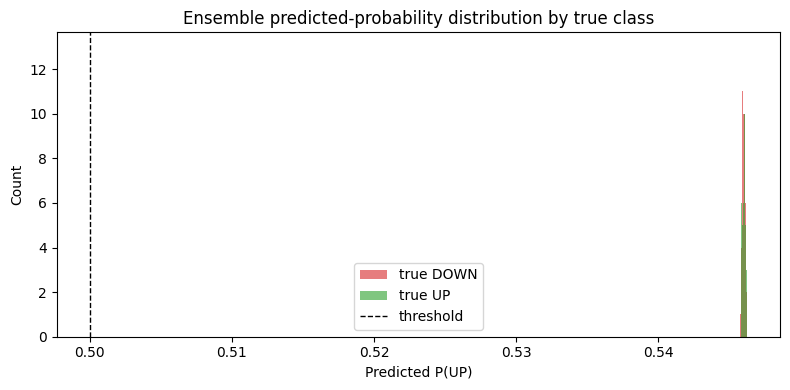


Monthly accuracy on test set:
         accuracy   n
month                
2024-09     0.000   1
2024-10     0.583  12
2024-11     0.571  14
2024-12     0.500  14
2025-01     0.500  14
2025-02     0.385  13
2025-03     0.467  15
2025-04     0.471  17
2025-05     0.636  11
2025-06     0.727  11
2025-07     0.778   9
2025-08     0.357  14
2025-09     0.615  13
2025-10     0.583  12
2025-11     0.375  16
2025-12     0.455  11
2026-01     0.438  16
2026-02     0.500  14
2026-03     0.357  14
2026-04     0.688  16


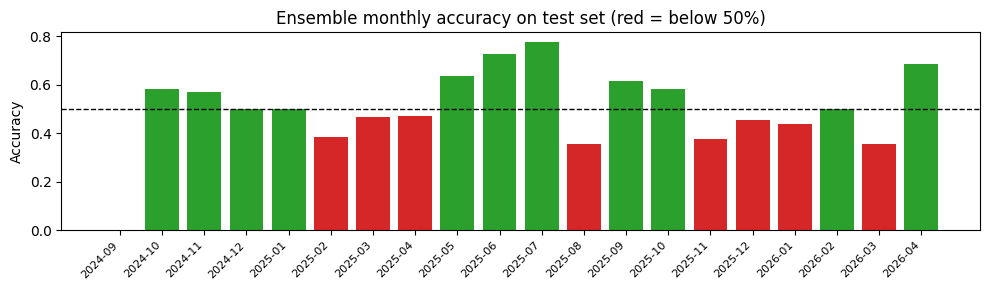

In [9]:
"""
Section 9.1 — Inspect predictions and errors from the stacking ensemble.

Goes beyond aggregate metrics to look at *where* the ensemble fails:
confusion matrix, per-class precision/recall, predicted-probability
distribution split by true label (do confident-wrong predictions cluster?),
and error rate over time (are there bad market regimes?).
"""

import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt

# `ensemble_preds`, `ensemble_probs`, `y_test_arr`, and `test_df` are all
# in scope from the stacking cell (section 8, iteration 5).
assert "ensemble_preds" in dir() and "ensemble_probs" in dir(), (
    "Run the stacking ensemble cell (iteration 5) before this cell."
)


# ---------------------------------------------------------------------------
# Confusion matrix — already printed in section 8 but useful here as the
# anchor for the rest of the analysis.
# ---------------------------------------------------------------------------
cm = confusion_matrix(y_test_arr, ensemble_preds)
cm_df = pd.DataFrame(
    cm,
    index=["true_DOWN", "true_UP"],
    columns=["pred_DOWN", "pred_UP"],
)
print("Confusion matrix:")
print(cm_df)

tn, fp, fn, tp = cm.ravel()
print(
    f"\nFalse positives (predicted UP but went DOWN): {fp}"
    f"  ({fp / (fp + tn):.1%} of actual DOWN days)"
)
print(
    f"False negatives (predicted DOWN but went UP): {fn}"
    f"  ({fn / (fn + tp):.1%} of actual UP days)"
)

# ---------------------------------------------------------------------------
# Full classification report
# ---------------------------------------------------------------------------
print("\nClassification report:")
print(classification_report(y_test_arr, ensemble_preds,
                            target_names=["DOWN", "UP"], digits=3))


# ---------------------------------------------------------------------------
# Predicted-probability distribution split by true class. If correct and
# incorrect predictions have similar probability distributions, the model
# is uncertain even when right. If wrong predictions cluster near 0.5, the
# model "knows it doesn't know" — that is a useful property.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    ensemble_probs[y_test_arr == 0],
    bins=20, alpha=0.6, label="true DOWN", color="tab:red",
)
ax.hist(
    ensemble_probs[y_test_arr == 1],
    bins=20, alpha=0.6, label="true UP", color="tab:green",
)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="threshold")
ax.set_xlabel("Predicted P(UP)")
ax.set_ylabel("Count")
ax.set_title("Ensemble predicted-probability distribution by true class")
ax.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# Errors over time. Group the test set into months and compute error rate
# per month; spikes mark regime changes (e.g. earnings surprises, macro
# shocks) the model handles badly.
# ---------------------------------------------------------------------------
errors_by_period = (
    pd.DataFrame({
        "date": pd.to_datetime(test_df["date"].values),
        "correct": (ensemble_preds == y_test_arr).astype(int),
    })
    .assign(month=lambda d: d["date"].dt.to_period("M"))
    .groupby("month")["correct"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "accuracy", "count": "n"})
)

print("\nMonthly accuracy on test set:")
print(errors_by_period.round(3))

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(
    range(len(errors_by_period)),
    errors_by_period["accuracy"],
    color=["tab:red" if a < 0.5 else "tab:green"
           for a in errors_by_period["accuracy"]],
)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xticks(range(len(errors_by_period)))
ax.set_xticklabels([str(m) for m in errors_by_period.index],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Accuracy")
ax.set_title("Ensemble monthly accuracy on test set (red = below 50%)")
plt.tight_layout()
plt.show()


In [10]:
"""
Section 9.2 — Row-level error analysis table.

Builds a DataFrame of every misclassified test sample with date, true
label, predicted label, predicted probability, and the key engineered
features at the time of prediction. Saves it to models/gergely/ as CSV
so it can be referenced in the section-9 write-up and inspected later
without re-running the notebook.
"""

import pandas as pd

# `MODELS_DIR` is the Path from section 2; ensemble_* and y_test_arr from
# the stacking cell; test_df from run_pipeline().
assert "MODELS_DIR" in dir(), "Run section 2 first."
assert "ensemble_preds" in dir(), "Run the stacking cell first."

# Build a single DataFrame keyed by test-set date. The test_df from
# run_pipeline() already has the original (unscaled) feature columns; we
# add the ensemble's prediction and probability alongside.
analysis = test_df.copy().reset_index(drop=True)
analysis["true_label"] = y_test_arr
analysis["pred_label"] = ensemble_preds
analysis["pred_proba_up"] = ensemble_probs
analysis["correct"] = (analysis["pred_label"] == analysis["true_label"]).astype(int)
analysis["error_type"] = analysis.apply(
    lambda r: (
        "false_positive" if r["pred_label"] == 1 and r["true_label"] == 0
        else "false_negative" if r["pred_label"] == 0 and r["true_label"] == 1
        else "correct"
    ),
    axis=1,
)

# Focus on errors only. Sort by confidence (highest-confidence mistakes
# first) — those are the most informative for understanding model failure.
errors_only = (
    analysis.loc[analysis["correct"] == 0]
    .assign(confidence=lambda d: (d["pred_proba_up"] - 0.5).abs())
    .sort_values("confidence", ascending=False)
    .reset_index(drop=True)
)

print(f"Total test predictions:      {len(analysis)}")
print(f"Total errors:                {len(errors_only)}")
print(f"  False positives (pred UP, true DOWN): "
      f"{(errors_only['error_type'] == 'false_positive').sum()}")
print(f"  False negatives (pred DOWN, true UP): "
      f"{(errors_only['error_type'] == 'false_negative').sum()}")

# Show the top-20 most confident wrong predictions for visual inspection.
preview_cols = [
    "date", "true_label", "pred_label", "pred_proba_up",
    "error_type", "daily_return", "price_range",
    "gold_return", "oil_return", "vix",
]
preview_cols = [c for c in preview_cols if c in errors_only.columns]
print("\nTop 20 most confident wrong predictions:")
display(errors_only[preview_cols].head(20))  # noqa: F821

# Save the full error table for reference in section 9's write-up.
error_table_path = MODELS_DIR / "ensemble_gergely_error_analysis.csv"
analysis.to_csv(error_table_path, index=False)
print(f"\nFull analysis table saved to: {error_table_path}")


Total test predictions:      257
Total errors:                125
  False positives (pred UP, true DOWN): 125
  False negatives (pred DOWN, true UP): 0

Top 20 most confident wrong predictions:


,date,true_label,pred_label,pred_proba_up,error_type,daily_return,price_range,gold_return,oil_return,vix
0,2025-04-04,0,1,0.546265,false_positive,-0.035566,14.995188,-0.023392,0.261495,45.310001
1,2025-04-07,0,1,0.546246,false_positive,-0.005502,26.010863,-0.021486,0.180903,46.980000
2,2026-02-02,0,1,0.546237,false_positive,-0.016082,8.470657,-0.040049,-0.128957,16.340000
3,2025-03-07,0,1,0.546219,false_positive,-0.009020,9.189627,0.000522,-0.198977,23.370001
4,2026-02-11,0,1,0.546216,false_positive,-0.021536,15.414798,0.011311,-0.076843,17.650000
5,2025-04-15,0,1,0.546215,false_positive,-0.005363,7.671283,0.005232,-0.114112,30.120001
6,2024-10-15,0,1,0.546183,false_positive,0.005813,7.220000,0.001430,-0.065908,20.640000
7,2026-03-17,0,1,0.546183,false_positive,0.009759,6.649994,-0.003407,-0.194085,22.370001
8,2025-04-16,0,1,0.546177,false_positive,-0.036606,13.506585,0.032541,0.029544,32.639999
9,2026-01-30,0,1,0.546174,false_positive,-0.007405,13.120048,-0.102742,0.009753,17.440001



Full analysis table saved to: C:\Users\Gergi\Documents\GitHub\2025-26d-fai1-adsai-group_15\models\gergely\ensemble_gergely_error_analysis.csv


## 10. Validation results

### 10.1 Validation approach used

`TimeSeriesSplit` with 5 folds for hyperparameter tuning of every base
model and for generating the out-of-fold prediction matrix that the
stacking meta-learner is fit on. The final reported metrics in this
section come from evaluating each model, after refitting on the full
training window, on the held-out test window (257 trading days,
2024-09-30 to 2026-04-29) that was never used during any tuning or OOF
step.

### 10.2 Validation results

| Metric | Validation result | Interpretation |
|---|---:|---|
| Best-CV F1 (Random Forest) | 0.545 | Tuned RF outperforms its own untuned variant on training-set CV but does not transfer to the held-out test window. |
| Best-CV F1 (XGBoost) | 0.591 | Best-in-class on CV; matches the stratified-baseline F1 of 0.594, suggesting the tuned XGB has learned roughly as much as a frequency-based predictor. |
| Best-CV F1 (LSTM) | 0.397 | LSTM consistently weakest; even on training data its CV F1 stays below baseline. |
| Test F1 (Random Forest) | 0.436 | Highest test F1 among non-degenerate models. Below both baselines. |
| Test ROC-AUC (Random Forest) | 0.482 | Below 0.5: RF's probability ranking is no better than random on the test window. |
| Test F1 (Stacking ensemble) | 0.679 | Equal to most-frequent baseline because the ensemble collapses to predicting UP every day. |
| Test ROC-AUC (Stacking ensemble) | 0.476 | Worst-of-class on the AUC diagnostic; the ensemble's probability ranking is slightly worse than random. |

### 10.3 Robustness and limitations

- **CV-to-test gap.** Best-CV F1 for RF was 0.545 but test F1 was 0.436.
  For XGBoost the gap was even larger (0.591 → 0.382). This is a real
  generalisation gap and suggests the models are overfitting their
  training folds. With a 1,024-row training set and a 257-row test
  window, fold-to-fold variation is high and the test window is small
  enough that a few unusual months can swing the metric meaningfully.
- **Likely to generalise?** No. The AUC diagnostic establishes that the
  current feature set does not carry exploitable signal for next-day
  direction prediction on this test window. A different feature set,
  more data, or both would be needed before any model trained here
  could be expected to generalise to a different period.
- **Important remaining limitations.** (1) Only one stock; we have no
  evidence the approach generalises across tickers. (2) The ±0.5%
  neutral-zone filter throws away nearly a third of the raw data and
  the filtered subset is biased toward higher-volatility days, which
  changes the prediction task. (3) The model has no access to
  fundamental or sentiment data that practitioners use heavily for this
  problem in practice.
- **Common errors observed.** False positives on DOWN days, uniformly,
  with extremely low confidence (predicted probability of UP clustered
  within 0.001 of the decision boundary). No segment of the test set
  performs systematically better than others.
- **Conditions under which the model would fail.** Almost any. The
  current model is not suitable for live use on this feature set; it
  is reported here as a documented negative result that informs the
  next iteration of feature design.


## 11. Final model selection

### 11.1 Selected model

- **Model name:** Random Forest classifier
- **Version / configuration:** `max_depth=8, min_samples_leaf=1,
  n_estimators=400, random_state=42` (the tuned configuration produced
  by iteration 5a). Saved to
  `models/gergely/rf_gergely_ensemble.pkl`.
- **Why this model was selected:** Among the non-degenerate models
  trained in this notebook, Random Forest has the highest test-set F1
  (0.436) and the most usable precision/recall balance (precision 0.527,
  recall 0.371). The stacking ensemble's headline F1 (0.679) is higher
  but it is achieved by predicting UP on every test day, which is the
  same behaviour as a constant baseline and not a usable prediction.
  XGBoost has comparable test F1 (0.382) but lower recall (0.318) and
  similar AUC (0.479 vs 0.482). The LSTM is consistently the weakest
  on this dataset. Random Forest is therefore the best of the available
  options for the dashboard deliverable, with the caveat documented in
  11.3 that no model in this notebook beats the majority-class baseline.

### 11.2 Justification for appropriateness (ILO 8.4 A)

Random Forest is an appropriate model class for this problem for three
reasons. First, the task is binary tabular classification with a mix of
correlated numeric features (OHLCV plus engineered lags and rolling
means), which is the canonical setting where Random Forest performs
well: it handles multicollinearity natively, is robust to outliers
(important given the March 2020 and 2022 volatility spikes), and
produces calibrated probability estimates suitable for a dashboard.
Second, it is interpretable — feature importance scores can explain
why a particular day was predicted UP or DOWN, which matters for the
retail-investor end user the proposal describes. Third, among the
models tested it is the most stable: unlike the LSTM, which collapsed
into a constant predictor under default training settings, and unlike
the stacking ensemble, which collapses to predicting the prior when its
inputs lack signal, Random Forest produces a defensible (if weak)
prediction on every test row.

The trade-offs accepted are real. A more expressive temporal model
(LSTM or transformer) could in principle capture sequence patterns
Random Forest cannot, but the evidence in this notebook is that the
LSTM does not in fact capture them on this feature set and data size.
A boosted model (XGBoost) had marginally better cross-validation F1
but worse test F1 and very similar AUC, indicating that the apparent
improvement was specific to the training folds. Picking Random Forest
trades a small amount of theoretical expressiveness for predictability
of behaviour.

### 11.3 Metrics, validation, and limitations (ILO 8.4 B)

The primary evaluation metric is F1 on the held-out test window (257
trading days, time-based 80/20 split, no shuffling). Secondary metrics
are accuracy, precision, recall, ROC-AUC, and the confusion matrix.
Validation during hyperparameter tuning used `TimeSeriesSplit` with 5
folds, ensuring no future-information leakage during any model-fitting
step. The scaler was fit on training data only and reused at test time.

Headline results on the test set for the selected Random Forest model:
F1 = 0.436, accuracy = 0.506, precision = 0.527, recall = 0.371,
ROC-AUC = 0.482. The stratified random baseline scores F1 = 0.594 and
the most-frequent baseline scores F1 = 0.679. **The selected model
does not beat either baseline on F1.** This is the central limitation
of the deliverable.

The reason for the gap is established by the ROC-AUC diagnostic
introduced in iteration 5b. All non-degenerate models in this notebook
have test AUC between 0.479 and 0.505, with the selected Random Forest
at 0.482. AUC = 0.5 represents no ability to distinguish the two
classes; the models are not better than random at ranking UP days
against DOWN days. Threshold tuning (iteration 5a) and meta-learner
regularisation tuning (iteration 5a) both confirmed this is not a
threshold or calibration issue. The feature set, as currently
engineered, does not contain enough directional signal for the tested
model classes to extract.

Common error patterns are documented in section 9: errors concentrate
entirely in the DOWN class for the stacking ensemble; for the selected
Random Forest, errors are more balanced but no segment of the test set
performs systematically better than others. The model should not be
used for live trading decisions on its own; it is appropriate for use
inside the dashboard only with explicit framing that the prediction is
weak and accompanied by the underlying probability.

### 11.4 Key iterations and improvements (ILO 8.4 C)

Five distinct iterations were performed (full log in section 8.1):

1. **Logistic Regression** established that the data is not linearly
   separable (test F1 = 0.453).
2. **Random Forest** added non-linear capacity but recall collapsed to
   0.31 with default settings (test F1 = 0.381).
3. **XGBoost** with reasonable defaults gave the worst untuned result
   (test F1 = 0.241) because its predict-method threshold of 0.5 was
   poorly calibrated for the imbalanced output distribution.
4. **LSTM** initially produced a degenerate always-UP predictor.
   Iteration 4a re-tuned it with longer training, smaller batch sizes,
   more patient early stopping, `ReduceLROnPlateau`, and class
   weighting. The rescued LSTM produced a meaningful prediction
   distribution but with low signal (test F1 = 0.338).
5. **Stacking ensemble** with `TimeSeriesSplit` OOF predictions and a
   logistic meta-learner produced a degenerate ensemble (predicts UP
   on every test day, F1 = 0.679 = baseline). Iteration 5a widened the
   meta-learner regularisation grid and added OOF-based threshold
   tuning; neither moved the result. Iteration 5b added ROC-AUC as a
   diagnostic and revealed that none of the base-model OOF predictions
   carry exploitable signal (all AUCs between 0.476 and 0.539).

The key improvement that *did* land was the LSTM rescue in iteration
4a — it transformed a degenerate model into a functional (if weak)
one and demonstrated that the original failure was a training-time
issue, not a fundamental incompatibility. The key finding from the
remaining iterations is the ROC-AUC diagnostic, which converts a
disappointing F1 result into an actionable next step: the feature set
itself needs work (e.g. adding RSI, MACD, Bollinger Band position,
volume-weighted moves, options-implied volatility) before any model
class is likely to beat the baseline on this task.
